In [1]:
import pandas as pd
import numpy as np
import zipfile
import requests
import io
from sklearn.preprocessing import StandardScaler

In [2]:
def load_electricity_data():
  # Step 1: Download zip
  url = "https://archive.ics.uci.edu/static/public/321/electricityloaddiagrams20112014.zip"
  response = requests.get(url)

  # Step 2: Extract zip in memory
  z = zipfile.ZipFile(io.BytesIO(response.content))

  # Step 3: Read the txt file inside zip
  file_name = z.namelist()[0]   # should be LD2011_2014.txt

  df = pd.read_csv(
      z.open(file_name),
      sep=";",
      decimal=",",
      parse_dates=[0],
      quotechar='"'
  )

  # Step 4: Fix datetime column
  df.rename(columns={df.columns[0]: "datetime"}, inplace=True)
  df.set_index("datetime", inplace=True)
  return df

In [3]:
df = load_electricity_data()

In [4]:
# Basic shape
print(df.shape)
# Check whether all values are zero
print((df == 0).all().all())
# Count non-zero values
print((df != 0).sum().sum())
# Summary stats
print(df.describe().T[["mean", "max"]].head(10))

(140256, 370)
False
41437378
              mean         max
MT_001    3.970785   48.223350
MT_002   20.768480  115.220484
MT_003    2.918308  151.172893
MT_004   82.184490  321.138211
MT_005   37.240309  150.000000
MT_006  141.227385  535.714286
MT_007    4.521338   44.657999
MT_008  191.401476  552.188552
MT_009   39.975354  157.342657
MT_010   42.205152  198.924731


In [5]:
df.isna().sum()[0]==1

/tmp/ipykernel_460/3011930760.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.isna().sum()[0]==1


np.False_

In [6]:
def aggregate_data(df):
  df["total_load"] = df.sum(axis=1)
  df_hourly = df["total_load"].resample("H").sum().to_frame()
  df_hourly.head()
  return df_hourly

In [7]:
df_hourly = aggregate_data(df)

/tmp/ipykernel_460/4251397852.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df["total_load"].resample("H").sum().to_frame()


In [8]:
def create_features(df_hourly):
  # If df_hourly is a Series, convert it to a DataFrame first
  if isinstance(df_hourly, pd.Series):
      df_hourly = df_hourly.to_frame(name="total_load")

  # Make sure index is datetime
  df_hourly.index = pd.to_datetime(df_hourly.index)

  # Create a copy so original stays untouched
  df_features = df_hourly.copy()

  # Basic calendar/time features
  df_features["hour_of_day"] = df_features.index.hour
  df_features["day_of_week"] = df_features.index.dayofweek   # Monday=0, Sunday=6
  df_features["is_weekend"] = (df_features["day_of_week"] >= 5).astype(int)
  df_features["month"] = df_features.index.month

  # Optional cyclical encoding
  df_features["hour_sin"] = np.sin(2 * np.pi * df_features["hour_of_day"] / 24)
  df_features["hour_cos"] = np.cos(2 * np.pi * df_features["hour_of_day"] / 24)

  df_features["dayofweek_sin"] = np.sin(2 * np.pi * df_features["day_of_week"] / 7)
  df_features["dayofweek_cos"] = np.cos(2 * np.pi * df_features["day_of_week"] / 7)

  df_features["month_sin"] = np.sin(2 * np.pi * (df_features["month"] - 1) / 12)
  df_features["month_cos"] = np.cos(2 * np.pi * (df_features["month"] - 1) / 12)

  return df_features

In [9]:
df_features = create_features(df_hourly)
print(df_features.head())
print(df_features.columns)

                        total_load  hour_of_day  day_of_week  is_weekend  \
datetime                                                                   
2011-01-01 00:00:00  207058.270272            0            5           1   
2011-01-01 01:00:00  265378.510747            1            5           1   
2011-01-01 02:00:00  263924.219533            2            5           1   
2011-01-01 03:00:00  266306.134264            3            5           1   
2011-01-01 04:00:00  259854.210701            4            5           1   

                     month  hour_sin  hour_cos  dayofweek_sin  dayofweek_cos  \
datetime                                                                       
2011-01-01 00:00:00      1  0.000000  1.000000      -0.974928      -0.222521   
2011-01-01 01:00:00      1  0.258819  0.965926      -0.974928      -0.222521   
2011-01-01 02:00:00      1  0.500000  0.866025      -0.974928      -0.222521   
2011-01-01 03:00:00      1  0.707107  0.707107      -0.974928      

In [10]:
df_features.head()

,total_load,hour_of_day,day_of_week,is_weekend,month,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,month_sin,month_cos
datetime,,,,,,,,,,,
2011-01-01 00:00:00,207058.270272,0,5,1,1,0.000000,1.000000,-0.974928,-0.222521,0.0,1.0
2011-01-01 01:00:00,265378.510747,1,5,1,1,0.258819,0.965926,-0.974928,-0.222521,0.0,1.0
2011-01-01 02:00:00,263924.219533,2,5,1,1,0.500000,0.866025,-0.974928,-0.222521,0.0,1.0
2011-01-01 03:00:00,266306.134264,3,5,1,1,0.707107,0.707107,-0.974928,-0.222521,0.0,1.0
2011-01-01 04:00:00,259854.210701,4,5,1,1,0.866025,0.500000,-0.974928,-0.222521,0.0,1.0


In [11]:
def check_outliers_iqr(df, target_col="total_load"):
    """
    Checks outliers in a numeric column using IQR rule.
    Returns summary dictionary and dataframe of outlier rows.
    """
    series = df[target_col].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (series < lower_bound) | (series > upper_bound)
    outliers = df.loc[outlier_mask]

    summary = {
        "target_col": target_col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "num_outliers": int(outlier_mask.sum()),
        "pct_outliers": round(100 * outlier_mask.mean(), 2)
    }

    return summary, outliers
summary, outliers = check_outliers_iqr(df_hourly, target_col="total_load")
print(summary)
print(outliers.head())

{'target_col': 'total_load', 'q1': np.float64(525816.5873144441), 'q3': np.float64(992780.6161335747), 'iqr': np.float64(466964.0288191306), 'lower_bound': np.float64(-174629.45591425174), 'upper_bound': np.float64(1693226.6593622705), 'num_outliers': 84, 'pct_outliers': np.float64(0.24)}
                       total_load
datetime                         
2012-07-17 16:00:00  1.697254e+06
2012-07-17 17:00:00  1.694787e+06
2012-07-18 14:00:00  1.711057e+06
2012-07-21 16:00:00  1.694772e+06
2012-08-09 16:00:00  1.709171e+06


In [12]:
def split_time_series(df, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    """
    Splits dataframe chronologically into train, val, test.
    Ratios must sum to 1.
    """
    if not np.isclose(train_ratio + val_ratio + test_ratio, 1.0):
        raise ValueError("train_ratio + val_ratio + test_ratio must equal 1.0")

    n = len(df)
    train_end = int(n * train_ratio)
    val_end = train_end + int(n * val_ratio)

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()

    return train_df, val_df, test_df

In [13]:
train_df, val_df, test_df = split_time_series(df_features)

In [14]:
def normalize_splits(train_df, val_df, test_df, feature_cols):
    """
    Fits StandardScaler on train_df[feature_cols] only,
    then transforms train/val/test using the same scaler.

    Returns scaled dataframes and fitted scaler.
    """
    scaler = StandardScaler()

    train_scaled = train_df.copy()
    val_scaled = val_df.copy()
    test_scaled = test_df.copy()

    train_scaled[feature_cols] = scaler.fit_transform(train_df[feature_cols])
    val_scaled[feature_cols] = scaler.transform(val_df[feature_cols])
    test_scaled[feature_cols] = scaler.transform(test_df[feature_cols])

    return train_scaled, val_scaled, test_scaled, scaler

In [15]:
feature_cols_to_scale = [
    "total_load"
]
train_scaled, val_scaled, test_scaled, scaler = normalize_splits(
    train_df, val_df, test_df, feature_cols_to_scale
)

In [16]:
train_scaled.head()

,total_load,hour_of_day,day_of_week,is_weekend,month,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,month_sin,month_cos
datetime,,,,,,,,,,,
2011-01-01 00:00:00,-1.577495,0,5,1,1,0.000000,1.000000,-0.974928,-0.222521,0.0,1.0
2011-01-01 01:00:00,-1.404373,1,5,1,1,0.258819,0.965926,-0.974928,-0.222521,0.0,1.0
2011-01-01 02:00:00,-1.408690,2,5,1,1,0.500000,0.866025,-0.974928,-0.222521,0.0,1.0
2011-01-01 03:00:00,-1.401619,3,5,1,1,0.707107,0.707107,-0.974928,-0.222521,0.0,1.0
2011-01-01 04:00:00,-1.420772,4,5,1,1,0.866025,0.500000,-0.974928,-0.222521,0.0,1.0


# time series overview graphs


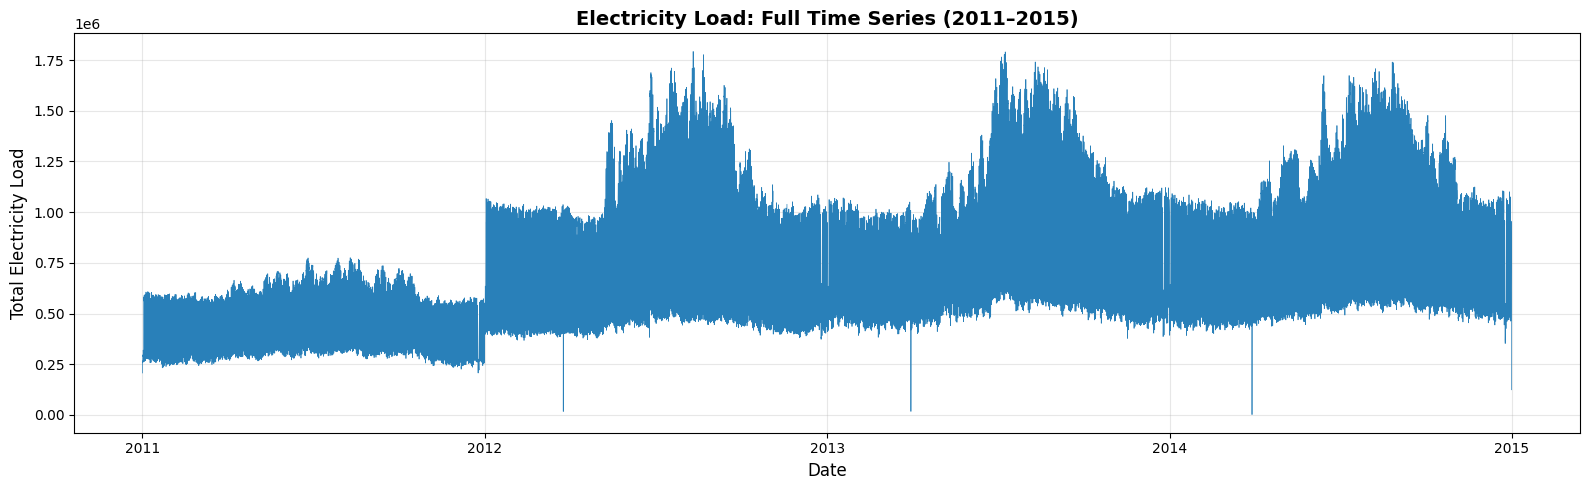

In [17]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_time_series_overview(df_hourly):
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(df_hourly.index, df_hourly['total_load'], linewidth=0.5, color='#2980b9')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Total Electricity Load', fontsize=12)
    ax.set_title('Electricity Load: Full Time Series (2011–2015)', fontsize=14, fontweight='bold')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_time_series_overview(df_hourly)

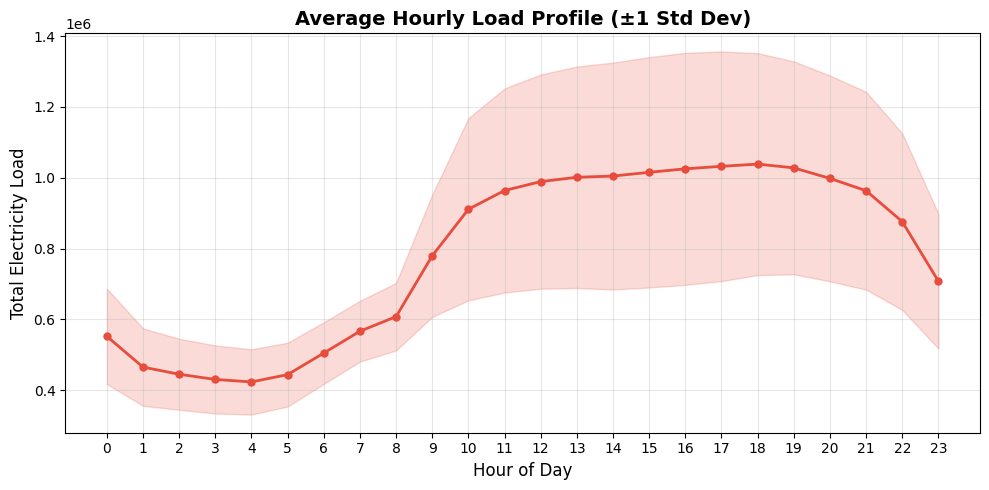

In [18]:
def plot_hourly_profile(df_features):
    hourly_avg = df_features.groupby('hour_of_day')['total_load'].mean()
    hourly_std = df_features.groupby('hour_of_day')['total_load'].std()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(hourly_avg.index, hourly_avg.values, color='#e74c3c', linewidth=2, marker='o', markersize=5)
    ax.fill_between(hourly_avg.index, hourly_avg - hourly_std, hourly_avg + hourly_std,
                    alpha=0.2, color='#e74c3c')
    ax.set_xlabel('Hour of Day', fontsize=12)
    ax.set_ylabel('Total Electricity Load', fontsize=12)
    ax.set_title('Average Hourly Load Profile (±1 Std Dev)', fontsize=14, fontweight='bold')
    ax.set_xticks(range(0, 24))
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_hourly_profile(df_features)

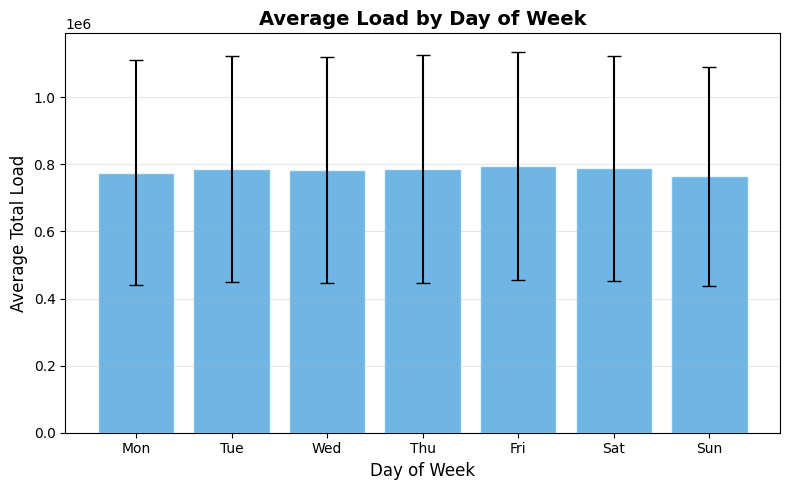

In [19]:
def plot_weekly_profile(df_features):
    day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    daily_avg = df_features.groupby('day_of_week')['total_load'].mean()
    daily_std = df_features.groupby('day_of_week')['total_load'].std()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(daily_avg.index, daily_avg.values, color='#3498db', alpha=0.7, edgecolor='white')
    ax.errorbar(daily_avg.index, daily_avg.values, yerr=daily_std.values,
                fmt='none', color='black', capsize=5)
    ax.set_xlabel('Day of Week', fontsize=12)
    ax.set_ylabel('Average Total Load', fontsize=12)
    ax.set_title('Average Load by Day of Week', fontsize=14, fontweight='bold')
    ax.set_xticks(range(7))
    ax.set_xticklabels(day_names)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

plot_weekly_profile(df_features)

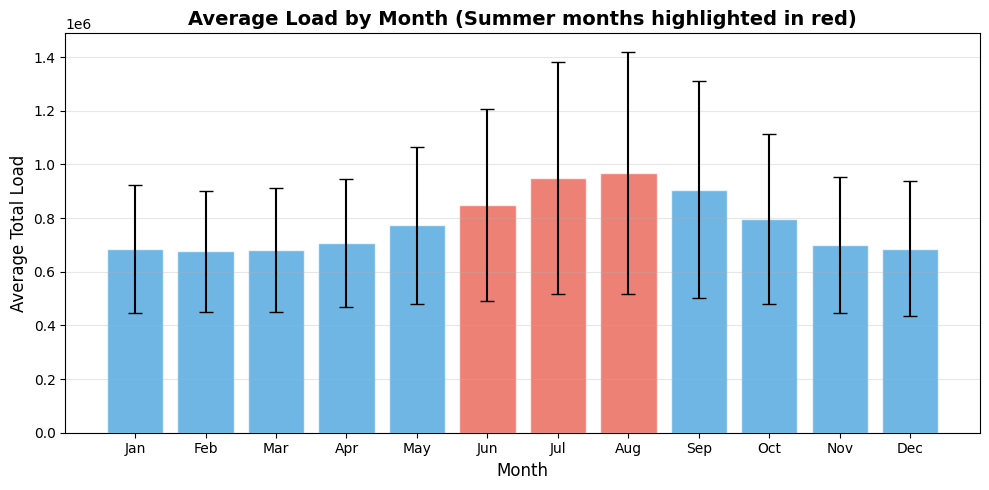

In [20]:
def plot_monthly_profile(df_features):
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    monthly_avg = df_features.groupby('month')['total_load'].mean()
    monthly_std = df_features.groupby('month')['total_load'].std()

    colors = ['#3498db'] * 12
    for i in [5, 6, 7]:  # summer months (Jun, Jul, Aug) highlighted
        colors[i] = '#e74c3c'

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(monthly_avg.index, monthly_avg.values, color=colors, alpha=0.7, edgecolor='white')
    ax.errorbar(monthly_avg.index, monthly_avg.values, yerr=monthly_std.values,
                fmt='none', color='black', capsize=5)
    ax.set_xlabel('Month', fontsize=12)
    ax.set_ylabel('Average Total Load', fontsize=12)
    ax.set_title('Average Load by Month (Summer months highlighted in red)', fontsize=14, fontweight='bold')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_names)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

plot_monthly_profile(df_features)

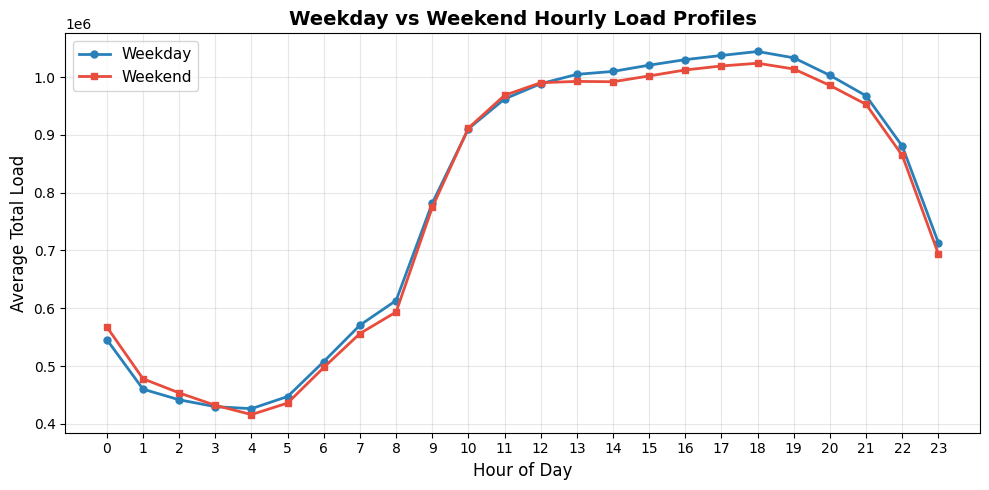

In [21]:
def plot_weekday_vs_weekend(df_features):
    weekday = df_features[df_features['is_weekend'] == 0].groupby('hour_of_day')['total_load'].mean()
    weekend = df_features[df_features['is_weekend'] == 1].groupby('hour_of_day')['total_load'].mean()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(weekday.index, weekday.values, color='#2980b9', linewidth=2, marker='o', markersize=5, label='Weekday')
    ax.plot(weekend.index, weekend.values, color='#e74c3c', linewidth=2, marker='s', markersize=5, label='Weekend')
    ax.set_xlabel('Hour of Day', fontsize=12)
    ax.set_ylabel('Average Total Load', fontsize=12)
    ax.set_title('Weekday vs Weekend Hourly Load Profiles', fontsize=14, fontweight='bold')
    ax.set_xticks(range(0, 24))
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_weekday_vs_weekend(df_features)

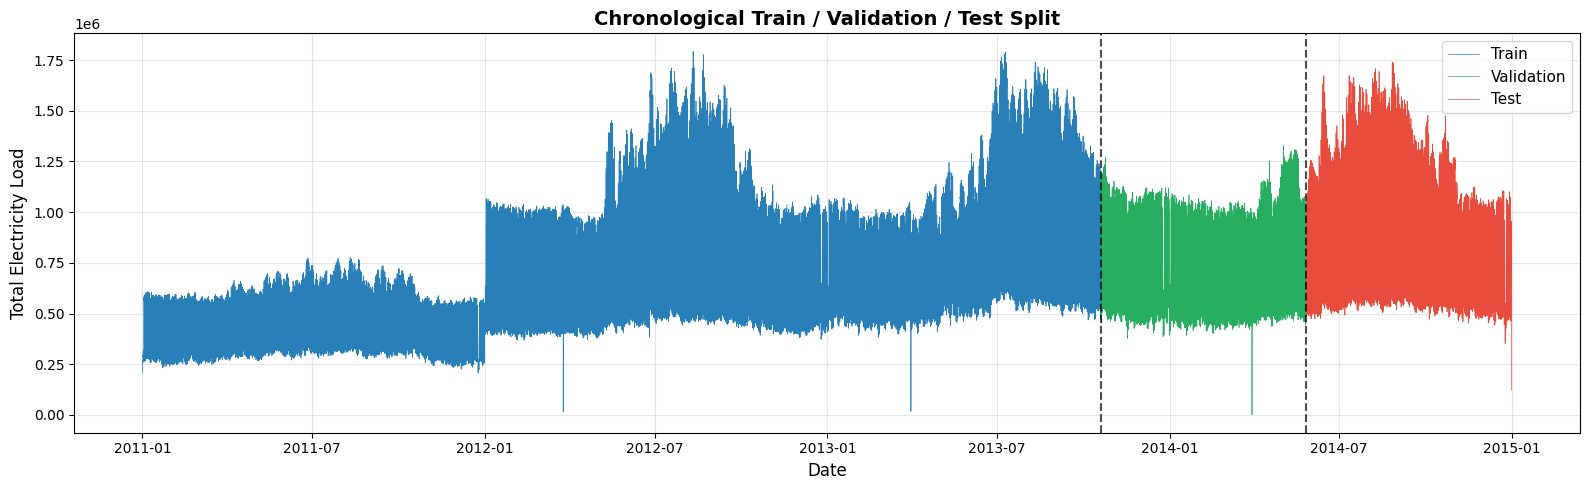

Train: 2011-01-01 to 2013-10-19 (24545 rows)
Val:   2013-10-19 to 2014-05-26 (5259 rows)
Test:  2014-05-26 to 2015-01-01 (5261 rows)


In [22]:
def plot_train_val_test_split(train_df, val_df, test_df):
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(train_df.index, train_df['total_load'], color='#2980b9', linewidth=0.5, label='Train')
    ax.plot(val_df.index, val_df['total_load'], color='#27ae60', linewidth=0.5, label='Validation')
    ax.plot(test_df.index, test_df['total_load'], color='#e74c3c', linewidth=0.5, label='Test')

    ax.axvline(x=val_df.index[0], color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axvline(x=test_df.index[0], color='black', linestyle='--', linewidth=1.5, alpha=0.7)

    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Total Electricity Load', fontsize=12)
    ax.set_title('Chronological Train / Validation / Test Split', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Train: {train_df.index.min().date()} to {train_df.index.max().date()} ({len(train_df)} rows)")
    print(f"Val:   {val_df.index.min().date()} to {val_df.index.max().date()} ({len(val_df)} rows)")
    print(f"Test:  {test_df.index.min().date()} to {test_df.index.max().date()} ({len(test_df)} rows)")

plot_train_val_test_split(train_df, val_df, test_df)

/tmp/ipykernel_460/3668536181.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(monthly_data, labels=month_names, patch_artist=True)


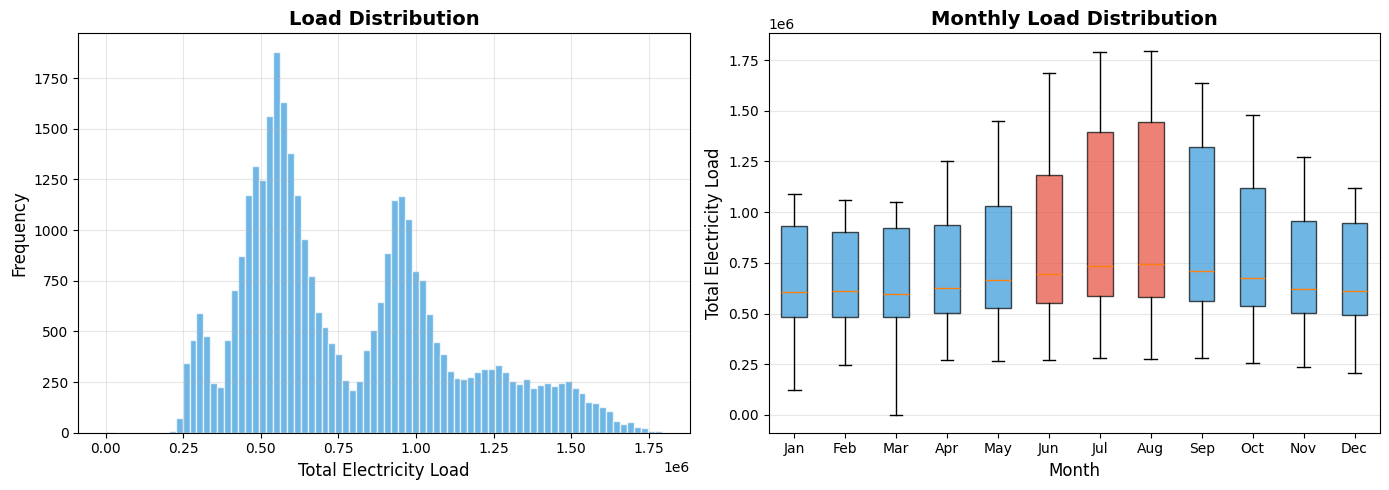

In [23]:
def plot_load_distribution(df_features):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    axes[0].hist(df_features['total_load'], bins=80, color='#3498db', alpha=0.7, edgecolor='white')
    axes[0].set_xlabel('Total Electricity Load', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('Load Distribution', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)

    # Box plot by month
    monthly_data = [df_features[df_features['month'] == m]['total_load'].values for m in range(1, 13)]
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    bp = axes[1].boxplot(monthly_data, labels=month_names, patch_artist=True)
    colors = ['#3498db'] * 5 + ['#e74c3c'] * 3 + ['#3498db'] * 4
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[1].set_xlabel('Month', fontsize=12)
    axes[1].set_ylabel('Total Electricity Load', fontsize=12)
    axes[1].set_title('Monthly Load Distribution', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

plot_load_distribution(df_features)